Test code to verify components of `gps.py` are working

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

import gps
import gps_sim
import prn

# Acquisition

In [2]:
f_s = 2.6e6
samples = np.fromfile("gpssim.bin", dtype=np.int8)

# f_s = 16.3676e6/2 # ???
# samples = np.fromfile("gnss0.bin", dtype=np.int8, count=int(f_s*5*2))
# f_if = 38400

# Convert to 1 bit
# samples = np.sign(samples)
# samples[samples == 0] = 1

# Convert to complex
samples = samples[::2].astype(np.complex64) + 1j*samples[1::2].astype(np.complex64)

# samples = gps_sim.generate_gps(f_s, int(f_s*4), 1, doppler=1040, code_phase=500, signal_power=-130)

# Add IF
# f_if = 100e3
# samples = samples * np.exp(2j*np.pi*f_if*np.arange(len(samples))/f_s)

# Normalize
# samples = samples / np.max(np.abs(samples))

# expected_sv = [3, 4, 9, 16, 26, 27, 28, 29, 31, 32]

In [3]:
results = gps.acquisition(samples, f_s, 10e3, 1000, f_if=0, verbose=True, threshold=5)

[Acquisition] Searching 1.58ms period, N=4096
[Acquisition] 634.8Hz frequency bins
[Acquisition] SV: 3, Doppler shift: -1269.53Hz, Code sample phase: 1308/2600, SNR: 9.6
[Acquisition] SV: 4, Doppler shift: 2539.06Hz, Code sample phase: 2385/2600, SNR: 5.5
[Acquisition] SV: 9, Doppler shift: 3808.59Hz, Code sample phase: 768/2600, SNR: 5.1
[Acquisition] SV: 16, Doppler shift: 2539.06Hz, Code sample phase: 1646/2600, SNR: 9.9
[Acquisition] SV: 26, Doppler shift: 0.00Hz, Code sample phase: 1186/2600, SNR: 14.9
[Acquisition] SV: 27, Doppler shift: 3808.59Hz, Code sample phase: 1510/2600, SNR: 5.4
[Acquisition] SV: 28, Doppler shift: -1904.30Hz, Code sample phase: 720/2600, SNR: 12.0
[Acquisition] SV: 29, Doppler shift: -1269.53Hz, Code sample phase: 467/2600, SNR: 5.1
[Acquisition] SV: 31, Doppler shift: -1269.53Hz, Code sample phase: 2393/2600, SNR: 6.9


In [4]:
def psd(x, f_s):
    X = np.abs(np.fft.fft(x) ** 2 / (len(x) * f_s))
    X = 10*np.log10(X)
    X = np.fft.fftshift(X)
    f = np.linspace(f_s/-2, f_s/2, len(x))

    return f, X

In [6]:
# Fine frequency acquisition with decimation
# Average every 4 or 8 (or some other power of 2) samples to decrease f_s, which
# should allow smaller frequency bins for the same size FFT. This only works after
# C/A code is removed from signal.

i = 2
fft_n = 8192
dec_factor = 8

print(gps.fine_acquisition(samples, f_s, fft_n, dec_factor, results[i][0], results[i][2]))

Sampling time: 0.025206153846153847 ms, resolution: 39.6728515625 Hz
3808.59375
3551.1537052862695


Text(0.5, 0, 'Frequency')

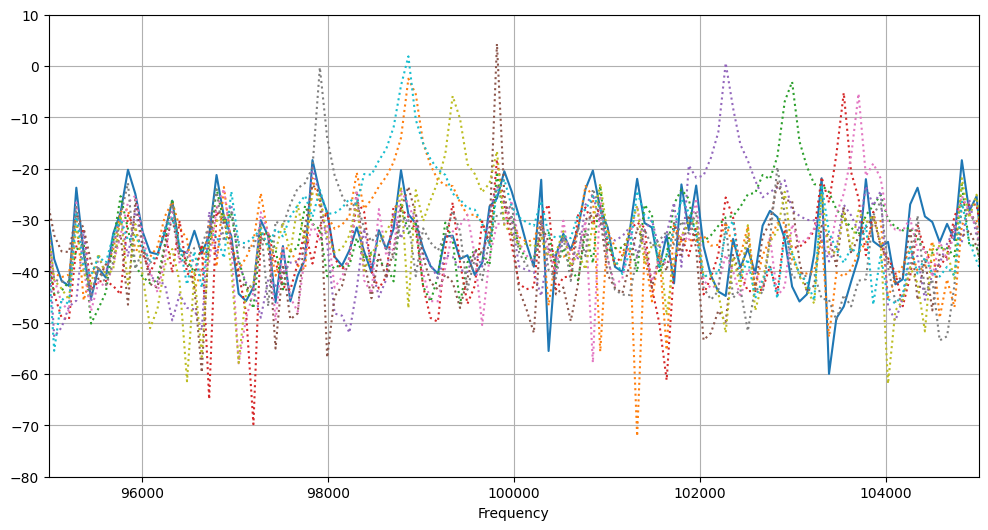

In [63]:
plt.figure(figsize=(12, 6))
f, X1 = psd(samples[0:2**15], f_s)
plt.plot(f, X1)

for i in range(len(results)):
    f, X2 = psd(samples[0:2**15] * prn.sample(results[i][0], f_s, 2**15, offset_samples=results[i][2]), f_s)
    plt.plot(f, X2, ':', label=f"SV {results[i][0]}")

plt.xlim([f_if-5e3, f_if+5e3])
plt.ylim([-80, 10])
plt.grid()
plt.xlabel("Frequency")

In [ ]:
# Fine frequency estimation attempt
fft_n = int(2 ** np.ceil(np.log2(f_s * 0.001)))
X = samples[0:fft_n] * prn.sample(results[i][0], f_s, fft_n, offset_samples=results[i][2])

(0.0, 0.0001)

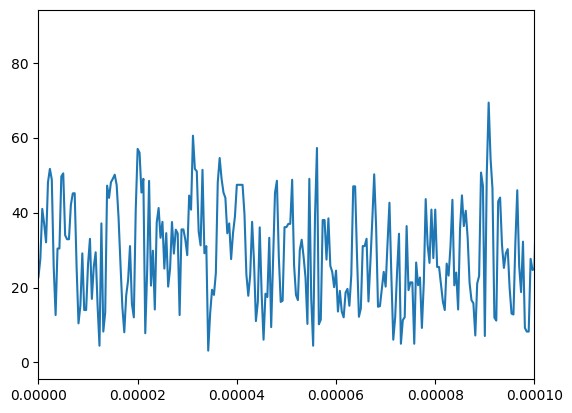

In [66]:
i = 1
# Summing decimation to f_s=100k
# dec = int(f_s / 200e3)
samples_despread = samples * prn.sample(results[i][0], f_s, len(samples), offset_samples=results[i][2])
# samples_despread = np.sum(samples_despread.reshape(-1, dec), axis=1)

# print(dec)

# plt.scatter(np.arange(len(samples_despread))/f_s, np.angle(samples_despread), s=1)
plt.plot(np.arange(len(samples_despread))/f_s, np.abs(samples_despread))
plt.xlim((0, 0.0001))